A k x k magic square is a k x k grid filled with integers such that every row sum, every column sum, and both diagonal sums are all equal. The integers in the magic square do not have to be distinct. Every 1 x 1 grid is trivially a magic square.

Given an m x n integer grid, return the size (i.e., the side length k) of the largest magic square that can be found within this grid.

 

Example 1:

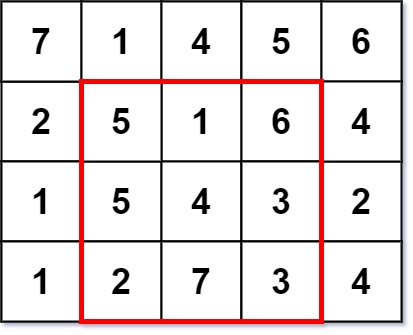

Input: grid = [[7,1,4,5,6],[2,5,1,6,4],[1,5,4,3,2],[1,2,7,3,4]]
Output: 3
Explanation: The largest magic square has a size of 3.
Every row sum, column sum, and diagonal sum of this magic square is equal to 12.
- Row sums: 5+1+6 = 5+4+3 = 2+7+3 = 12
- Column sums: 5+5+2 = 1+4+7 = 6+3+3 = 12
- Diagonal sums: 5+4+3 = 6+4+2 = 12

Example 2:

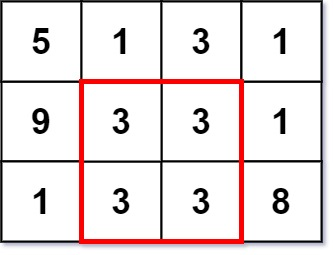

Input: grid = [[5,1,3,1],[9,3,3,1],[1,3,3,8]]
Output: 2

 

Constraints:

    m == grid.length
    n == grid[i].length
    1 <= m, n <= 50
    1 <= grid[i][j] <= 106



In [ ]:
class Solution:
    def largestMagicSquare(self, grid: List[List[int]]) -> int:
        m, n = len(grid), len(grid[0])

        rowsum = [[0] * n for _ in range(m)]
        for i in range(m):
            rowsum[i][0] = grid[i][0]
            for j in range(1, n):
                rowsum[i][j] = rowsum[i][j - 1] + grid[i][j]

        colsum = [[0] * n for _ in range(m)]
        for j in range(n):
            colsum[0][j] = grid[0][j]
            for i in range(1, m):
                colsum[i][j] = colsum[i - 1][j] + grid[i][j]

        for edge in range(min(m, n), 1, -1):
            # top-left corner position of the square
            for i in range(m - edge + 1):
                for j in range(n - edge + 1):
                    stdsum = rowsum[i][j + edge - 1] - (
                        0 if j == 0 else rowsum[i][j - 1]
                    )
                    check = True
                    for ii in range(i + 1, i + edge):
                        if (
                            rowsum[ii][j + edge - 1]
                            - (0 if j == 0 else rowsum[ii][j - 1])
                            != stdsum
                        ):
                            check = False
                            break
                    if not check:
                        continue

                    for jj in range(j, j + edge):
                        if (
                            colsum[i + edge - 1][jj]
                            - (0 if i == 0 else colsum[i - 1][jj])
                            != stdsum
                        ):
                            check = False
                            break
                    if not check:
                        continue

                    d1 = d2 = 0
                    for k in range(edge):
                        d1 += grid[i + k][j + k]
                        d2 += grid[i + k][j + edge - 1 - k]
                    if d1 == stdsum and d2 == stdsum:
                        return edge

        return 1